In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import os
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go
import plotly.io as pio
from matplotlib.widgets import Slider
import ipywidgets as widgets
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import seaborn as sns
from shapely.geometry import Point, Polygon as ShapelyPolygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import imageio

import cmocean
import cmocean.cm as cmo
import importlib
import utils  # Importing the utils module
import cbmaps
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from matplotlib import rcParams
import matplotlib.font_manager as fm


import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
from matplotlib.offsetbox import AnchoredOffsetbox, AuxTransformBox


In [2]:
# Import Utils for consistent naming, colors, labling, and mapping
importlib.reload(utils) # Run this if you update something in your utils file you need

stages = utils.stages
stage_colors = {key: value['color'] for key, value in stages.items()}
stage_labels = {key: value['label'] for key, value in stages.items()}
stage_markers = {key: value['marker'] for key, value in stages.items()}
stage_duration = {key: value['duration'] for key, value in stages.items()}

# Different Hypotheses (in this case only hi res)
hypotheses = utils.hypotheses
hypotheses_name = {key: value['name'] for key, value in hypotheses.items()}
hypothesis_labels = {key: value['label'] for key, value in hypotheses.items()}
hypothesis_order = {key: value['order'] for key, value in hypotheses.items()}


In [3]:
def load_custom_font(variant="Light"):
    """Load the specified Aptos font variant."""
    font_path = f"/Library/Fonts/Aptos-{variant}.ttf"
    try:
        aptos_font = fm.FontProperties(fname=font_path)
        print(f"Using font: {aptos_font.get_name()}")
        return aptos_font
    except Exception as e:
        print(f"Error loading font: {e}")
        return None  # Return None if font loading fails


def add_stage_rectangles(ax, stages, font):
    """Add stage rectangles and labels to the axes."""
    for i, (stage, info) in enumerate(stages.items()):
        # Create a colored rectangle for each stage
        rect = Rectangle((i * 2, 0.4), width=1.5, height=0.5, color=info['color'])
        ax.add_patch(rect)

        # Add the stage label and duration inside the rectangle
        ax.text(
            i * 2 + 0.75, 0.65, 
            f"{info['label']}\n({info['duration']})",
            va='center', ha='center', fontsize=40, fontproperties=font, color='white'
        )


def add_arrows_between_stages(ax, num_stages):
    """Add arrows between consecutive stages."""
    for i in range(num_stages - 1):
        arrow = FancyArrowPatch(
            (i * 2 + 1.5, 0.65), ((i + 1) * 2, 0.65),
            arrowstyle='->,head_width=0.5,head_length=0.7', linewidth=7,
            mutation_scale=25, color='black'
        )
        ax.add_patch(arrow)


def configure_and_save_plot(num_stages, save_path=None):
    """Configure plot layout and save if a path is provided."""
    fig, ax = plt.subplots(figsize=(num_stages * 4, 4))
    ax.set_xlim(0, num_stages * 2)
    ax.set_ylim(0, 1)
    ax.axis('off')  # Hide axes

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0, transparent=True)
        print(f"Saved lifecycle key to {save_path}")

    return fig, ax

In [4]:
def plot_lifecycle_key(stages, font_variant="Light", save_path=None):
    """Main function to generate the lifecycle key."""
    # Load the custom font (or fallback to default)
    font = load_custom_font(font_variant)
    if font is None:
        print("Using default font as fallback.")

    num_stages = len(stages)

    # Configure plot
    fig, ax = configure_and_save_plot(num_stages)

    # Add stage rectangles and labels
    add_stage_rectangles(ax, stages, font)

    # Add arrows between stages
    add_arrows_between_stages(ax, num_stages)

    # Refresh and render the canvas to avoid blank outputs
    fig.canvas.draw()

    # Save the plot with a transparent background if a save path is provided
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0, transparent=True)
        print(f"Saved lifecycle key to {save_path}")

    # Display the plot
    plt.show()

Using font: Aptos
Saved lifecycle key to Fig-Lib/lifecycle_key.png


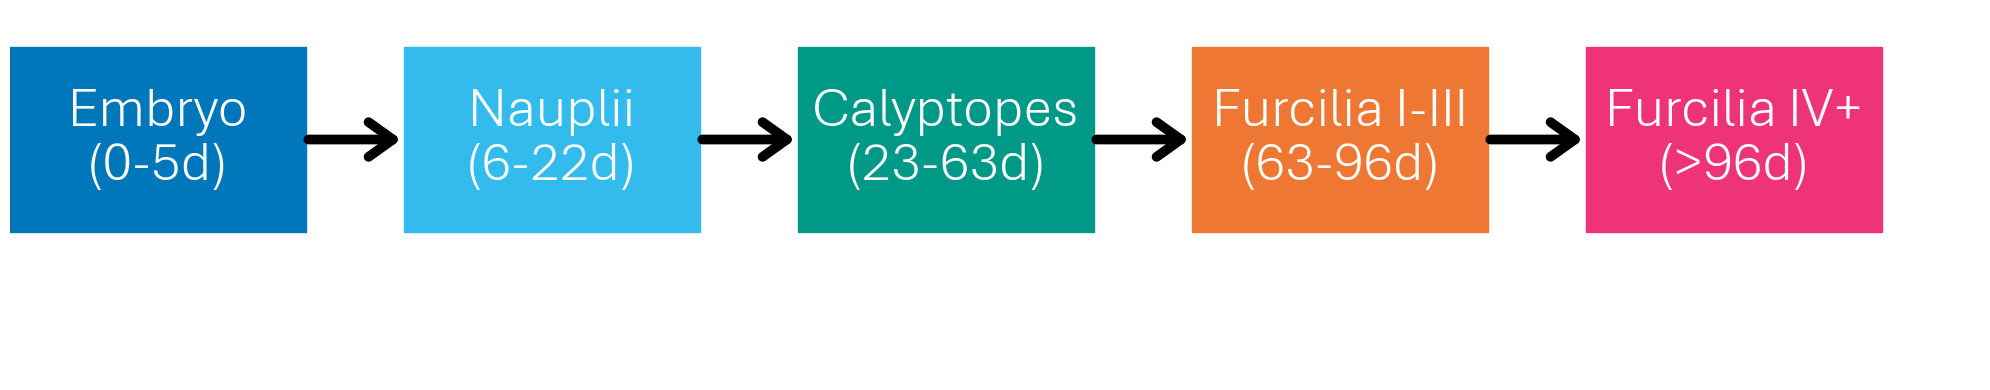

In [5]:
plot_lifecycle_key(stages, save_path="Fig-Lib/lifecycle_key.png")

# Generate Vertical Depth Profiles:
1) Standard DVM
2) Modified DVM no ice
3) Modified DVM with ice

In [6]:
# Shared vertical profile constants
profile_constants = {
    "release_depth": -5,  # Initial release depth (m)
    "sinking_rate": 145 / 24,  # m/hour
    "initial_sinking_time": 120,  # Hours
    "ascent_rate": 68.2 / 24,  # m/hour
    "dvm_start_hour": 63 * 24,  # DVM starts at 63 days
    "dvm_velocity": 0.016 * 3600,  # m/hour
}

# Define the stage hour ranges for the full 180-day profile
stage_hour_ranges = {
    0: (0, 120),         # Embryo: 0–120 hours (0–5 days)
    1: (121, 528),       # Nauplii: 121–528 hours (6–22 days)
    2: (529, 1512),      # Calyptopes: 529–1512 hours (23–63 days)
    3: (1513, 2305),     # Furcilia I–III: 1513–2304 hours (64–96 days)
    4: (2304, 4320)      # Furcilia IV+: 2305–4320 hours (97–180 days)
}

# Sunrise and sunset times for March 15 at three locations
sunrise_sunset_times = {
    "elephant_island": {"sunrise": 5 + 30 / 60, "sunset": 18 + 10 / 60},  # Times in hours
    "palmer_station": {"sunrise": 7, "sunset": 19 + 45 / 60},
    "adelaide_island": {"sunrise": 7 + 15 / 60, "sunset": 20 + 15 / 60},
}

In [7]:
def generate_vertical_profile_standard_dvm(duration=180, location=None):
    """
    Generates the vertical profile for standard DVM using location-based sunrise/sunset times.

    Parameters:
    - duration: Simulation duration in days.
    - location: A dictionary containing sunrise and sunset times for a specific location.

    Returns:
    - hours: Time in hours.
    - depths: Depths corresponding to each time step.
    """
    if location is None or "sunrise" not in location or "sunset" not in location:
        raise ValueError("A valid location dictionary with 'sunrise' and 'sunset' keys must be provided.")
    # Fetch constants
    release_depth = profile_constants["release_depth"]
    sinking_rate = profile_constants["sinking_rate"]
    initial_sinking_time = profile_constants["initial_sinking_time"]
    ascent_rate = profile_constants["ascent_rate"]
    dvm_start_hour = profile_constants["dvm_start_hour"]
    dvm_velocity = profile_constants["dvm_velocity"]

    # DVM parameters
    sunrise_hour = location["sunrise"]
    sunset_hour = location["sunset"]

    # Initialize time and depth arrays
    hours = np.arange(duration * 24)  # Total duration in hourly intervals
    depths = np.full_like(hours, release_depth, dtype=float)  # Start at release depth

    # Phase 1: Initial Sinking (0–120 hours)
    for hour in range(initial_sinking_time):
        depths[hour] = max(release_depth - hour * sinking_rate, -800)

    # Phase 2: Ascent (121–1512 hours)
    ascent_start = initial_sinking_time
    for hour in range(ascent_start, dvm_start_hour):
        depths[hour] = min(depths[ascent_start - 1] + (hour - ascent_start) * ascent_rate, release_depth)

    # Phase 3: STANDARD DVM (1512–4320 hours)
    for hour in range(dvm_start_hour, duration * 24):
        day_fraction = hour % 24  # Current hour of the day

        if sunrise_hour <= day_fraction < sunset_hour:  # Daytime: Downward
            depths[hour] = max(depths[hour - 1] - dvm_velocity, -150)
        else:  # Nighttime: Upward
            depths[hour] = min(depths[hour - 1] + dvm_velocity, -1.5)

    return hours, depths

In [8]:
def generate_vertical_profile_deep_dvm(duration=180, location=None):
    if location is None or "sunrise" not in location or "sunset" not in location:
        raise ValueError("A valid location dictionary with 'sunrise' and 'sunset' keys must be provided.")
    # Fetch constants
    release_depth = profile_constants["release_depth"]
    sinking_rate = profile_constants["sinking_rate"]
    initial_sinking_time = profile_constants["initial_sinking_time"]
    ascent_rate = profile_constants["ascent_rate"]
    dvm_start_hour = profile_constants["dvm_start_hour"]
    dvm_velocity = profile_constants["dvm_velocity"]

    # DVM parameters
    sunrise_hour = location["sunrise"]
    sunset_hour = location["sunset"]

    # Initialize time and depth arrays
    hours = np.arange(duration * 24)  # Total duration in hourly intervals
    depths = np.full_like(hours, release_depth, dtype=float)  # Start at release depth

    # Phase 1: Initial Sinking (0–120 hours)
    for hour in range(initial_sinking_time):
        depths[hour] = max(release_depth - hour * sinking_rate, -800)

    # Phase 2: Ascent (121–1512 hours)
    ascent_start = initial_sinking_time
    for hour in range(ascent_start, dvm_start_hour):
        depths[hour] = min(depths[ascent_start - 1] + (hour - ascent_start) * ascent_rate, release_depth)

    # Phase 3: DEEP DVM (1512–4320 hours)
    for hour in range(dvm_start_hour, duration * 24):
        day_fraction = hour % 24  # Current hour of the day

        if sunrise_hour <= day_fraction < sunset_hour:  # Daytime: Downward
            depths[hour] = max(depths[hour - 1] - dvm_velocity, -200)
        else:  # Nighttime: Upward
            depths[hour] = min(depths[hour - 1] + dvm_velocity, -1.5)

    return hours, depths

In [9]:
def generate_vertical_profile_reverse_dvm(duration=180, location=None):
    if location is None or "sunrise" not in location or "sunset" not in location:
        raise ValueError("A valid location dictionary with 'sunrise' and 'sunset' keys must be provided.")
    # Fetch constants
    release_depth = profile_constants["release_depth"]
    sinking_rate = profile_constants["sinking_rate"]
    initial_sinking_time = profile_constants["initial_sinking_time"]
    ascent_rate = profile_constants["ascent_rate"]
    dvm_start_hour = profile_constants["dvm_start_hour"]
    dvm_velocity = profile_constants["dvm_velocity"]

    # DVM parameters
    sunrise_hour = location["sunrise"]
    sunset_hour = location["sunset"]
    max_reverse_dvm_depth = -200  # Max depth during DVM in reverse DVM
    min_reverse_dvm_depth = -20  # Min depth during reverse DVM
    
    # Initialize time and depth arrays
    hours = np.arange(duration * 24)  # Total duration in hourly intervals
    depths = np.full_like(hours, release_depth, dtype=float)  # Start at release depth

    # Phase 1: Initial Sinking (0–120 hours)
    for hour in range(initial_sinking_time):
        depths[hour] = max(release_depth - hour * sinking_rate, -800)

    # Phase 2: Ascent (121–1512 hours)
    ascent_start = initial_sinking_time
    for hour in range(ascent_start, dvm_start_hour):
        depths[hour] = min(depths[ascent_start - 1] + (hour - ascent_start) * ascent_rate, release_depth)

    # Phase 3: Reverse DVM (1512–4320 hours)
    for hour in range(dvm_start_hour, duration * 24):
        day_fraction = hour % 24  # Hour within the day

        if sunrise_hour <= day_fraction < sunset_hour:  # Daytime: Move upward
            if depths[hour - 1] < -1.5:
                depths[hour] = min(depths[hour - 1] + dvm_velocity, -1.5)
            else:
                depths[hour] = -1.5  # Clamp depth at surface limit
        else:  # Nighttime: Move downward
            if depths[hour - 1] > min_reverse_dvm_depth:
                depths[hour] = max(depths[hour - 1] - dvm_velocity, min_reverse_dvm_depth)
            else:
                depths[hour] = min_reverse_dvm_depth  # Clamp depth at 20 m

    return hours, depths

In [20]:
# Select a location
location = sunrise_sunset_times["palmer_station"]
loc_name = 'Anvers Island'
loc_date = 'March 15'


# Generate the profile
hours_s, depths_s = generate_vertical_profile_standard_dvm(duration=180, location=location)
hours_d, depths_d = generate_vertical_profile_deep_dvm(duration=180, location=location)
hours_r, depths_r = generate_vertical_profile_reverse_dvm(duration=180, location=location)

# # Example: Print first 10 hours and depths
# for h, d in zip(hours[:10], depths[:10]):
#     print(f"Hour: {h}, Depth: {d}")

# Plot Standard Full Vertical Profile and Lifecycle

In [11]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle
import matplotlib.image as mpimg


In [12]:
def plot_vertical_profile_with_embedded_key(
    hours, depths, stage_colors, stage_hour_ranges, stages,
    key_image_path, title, location=None, loc_date=None,
    zoom_xlim=None, zoom_ylim=(-800, 5), x_tick_interval=25, save_path=None
):
    """
    Plots the vertical profile with daily labels and embeds a lifecycle key image in the lower right corner.

    Parameters:
    - hours: array of time in hours.
    - depths: array of depths corresponding to hours.
    - stage_colors: dictionary of stage colors.
    - stage_hour_ranges: dictionary of stage hour ranges.
    - stages: lifecycle stages dictionary.
    - key_image_path: path to the lifecycle key image (PNG or JPG).
    - title: Title for the plot (e.g., "Standard DVM Pattern").
    - location: Optional string indicating the location of the profile (e.g., "Anvers Island").
    - loc_date: Optional string indicating the date (e.g., "March 15").
    - zoom_xlim: Tuple (min_day, max_day) for the x-axis zoom range (in days).
    - zoom_ylim: Tuple (min_depth, max_depth) for the y-axis zoom range (in meters).
    - x_tick_interval: Interval for x-axis ticks (in days).
    - save_path: Optional path to save the final plot.
    """
    # Validate the key image file
    try:
        img = mpimg.imread(key_image_path)
    except FileNotFoundError:
        raise ValueError(f"Key image file not found at {key_image_path}")

    # Set zoom limits for x-axis
    if zoom_xlim is None:
        zoom_xlim = (0, hours[-1] / 24)  # Full range if not provided

    # Use constrained_layout for better handling of insets
    fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

    # Title with optional location/date
    full_title = title
    if location and loc_date:
        full_title += f"\n{location} ({loc_date})"
    ax.set_title(full_title, fontsize=16)

    # Plot segments of the line with different colors based on life stages
    for stage, (start_hour, end_hour) in stage_hour_ranges.items():
        start_idx = max(0, np.searchsorted(hours, start_hour))
        end_idx = min(len(hours), np.searchsorted(hours, end_hour))

        ax.plot(
            hours[start_idx:end_idx] / 24,  # Convert hours to days
            depths[start_idx:end_idx],
            color=stage_colors[stage], linewidth=3, label=f"{stages[stage]['label']} ({int(start_hour / 24)}-{int(end_hour / 24)} days)"
        )

    # Set axis labels
    ax.set_xlabel("Time (days)", fontsize=14)
    ax.set_ylabel("Depth (m)", fontsize=14)

    # Invert the y-axis so 0 m (surface) is at the top
    ax.set_ylim(zoom_ylim)
    ax.set_xlim(zoom_xlim)  # Apply zoom limits to x-axis

    # Set x-axis ticks at specified intervals
    ax.set_xticks(range(int(zoom_xlim[0]), int(zoom_xlim[1]) + 1, x_tick_interval))

    # Embed the lifecycle key image in the lower right
    inset_ax = inset_axes(ax, width="75%", height="37%", loc="lower right", borderpad=0)
    inset_ax.axis("off")  # Turn off axes for the inset
    inset_ax.imshow(img)
    inset_ax.set_aspect("auto")  # Ensure the image scales properly

    # Save the plot if save_path is provided
    if save_path:
        if isinstance(save_path, str):  # Check that save_path is a string
            plt.savefig(save_path, dpi=100, bbox_inches="tight", pad_inches=0.1)
            print(f"Plot saved to {save_path}")
        else:
            print(f"Error: save_path must be a string, got {type(save_path)}")

    # Show the plot
    plt.show()

Plot saved to figures/manuscript-versions/fig_4_3_dvm_schematic.pdf


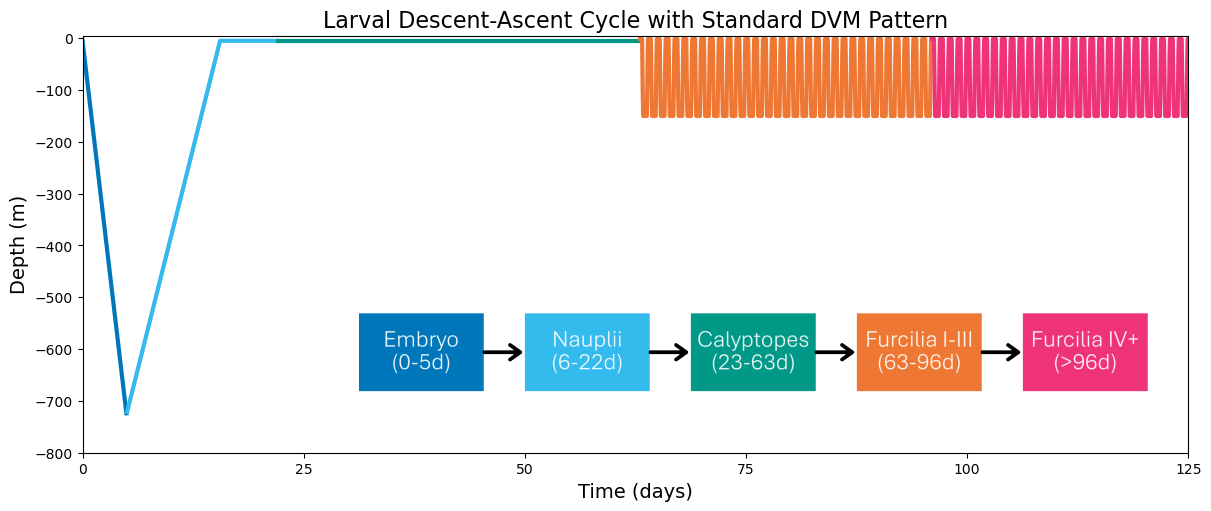

In [13]:
# Plot the vertical profile for Standard DVM
plot_vertical_profile_with_embedded_key(
    hours=hours_s,
    depths=depths_s,
    stage_colors=stage_colors,
    stage_hour_ranges=stage_hour_ranges,
    stages=stages,
    key_image_path='Fig-Lib/lifecycle_key.png',
    title="Larval Descent-Ascent Cycle with Standard DVM Pattern",
    zoom_xlim=(0, 125),  # truncated range
    zoom_ylim=(-800, 5),  # Standard depth range
    x_tick_interval=25,
    # save_path="figures/manuscript-versions/standard_dvm_schematic.pdf",
    save_path="figures/manuscript-versions/fig_4_3_dvm_schematic.pdf"
)

Plot saved to figures/manuscript-versions/fig_4_3_dvm_schematic.png


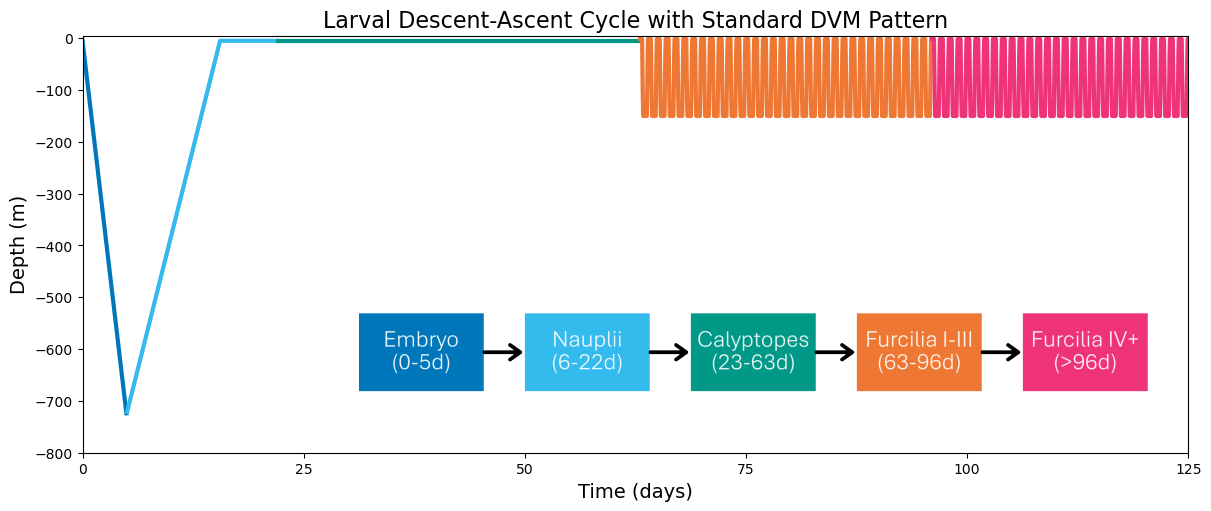

In [14]:
# Plot the vertical profile for Standard DVM
plot_vertical_profile_with_embedded_key(
    hours=hours_s,
    depths=depths_s,
    stage_colors=stage_colors,
    stage_hour_ranges=stage_hour_ranges,
    stages=stages,
    key_image_path='Fig-Lib/lifecycle_key.png',
    title="Larval Descent-Ascent Cycle with Standard DVM Pattern",
    zoom_xlim=(0, 125),  # truncated range
    zoom_ylim=(-800, 5),  # Standard depth range
    x_tick_interval=25,
    # save_path="figures/manuscript-versions/standard_dvm_schematic.pdf",
    save_path="figures/manuscript-versions/fig_4_3_dvm_schematic.png"
)

# Zoomed in plots of different DVM profiles

In [15]:
def dvm_zoom(
    hours, depths, stage_colors, stage_hour_ranges, location, 
    title, zoom_xlim=(95 * 24, 105 * 24), zoom_ylim=(-250, 5),
    loc_name=None, loc_date=None, save_path=None
):
    """
    Plots a zoomed-in view of the DVM pattern with day/night shading.

    Parameters:
    - hours: array of time in hours.
    - depths: array of depths corresponding to hours.
    - stage_colors: dictionary of stage colors.
    - stage_hour_ranges: dictionary of stage hour ranges.
    - location: Dictionary containing sunrise and sunset times.
    - title: Title for the plot, describing the DVM type.
    - zoom_xlim: Tuple (min_hour, max_hour) for the x-axis zoom.
    - zoom_ylim: Tuple (min_depth, max_depth) for the y-axis zoom.
    - loc_name: Optional string for the location name (e.g., "Palmer Station").
    - loc_date: Optional string for the date (e.g., "March 15").
    - save_path: Optional path to save the figure.
    """
    if "sunrise" not in location or "sunset" not in location:
        raise ValueError("Location must include 'sunrise' and 'sunset' times.")

    sunrise_hour = location["sunrise"]
    sunset_hour = location["sunset"]

    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_title(title, fontsize=12)

    # Determine night blocks within the zoom_xlim
    start_hour = int(zoom_xlim[0])
    end_hour = int(zoom_xlim[1])
    current_block_start = None

    for hour in range(start_hour, end_hour):
        day_fraction = hour % 24  # Hour within the day
        if not (sunrise_hour <= day_fraction < sunset_hour):  # Nighttime
            if current_block_start is None:
                current_block_start = hour  # Start of a night block
        else:  # Daytime
            if current_block_start is not None:
                ax.axvspan(
                    current_block_start / 24, hour / 24,  # Convert hours to days
                    color='lightblue', alpha=0.3  # Night shading
                )
                current_block_start = None

    # If there's an ongoing night block at the end, close it
    if current_block_start is not None:
        ax.axvspan(
            current_block_start / 24, end_hour / 24,  # Convert hours to days
            color='lightblue', alpha=0.3
        )

    # Plot the DVM phase
    for stage, (start_hour, end_hour) in stage_hour_ranges.items():
        if end_hour < zoom_xlim[0] or start_hour > zoom_xlim[1]:
            continue
        
        start_idx = max(0, np.searchsorted(hours, max(start_hour, zoom_xlim[0])))
        end_idx = min(len(hours), np.searchsorted(hours, min(end_hour, zoom_xlim[1])))

        ax.plot(
            hours[start_idx:end_idx] / 24,  # Convert hours to days
            depths[start_idx:end_idx],
            color=stage_colors[stage], linewidth=3, label=f"{stages[stage]['label']} ({int(start_hour/24)}-{int(end_hour/24)} days)"
        )

    # Set zoomed axis limits
    ax.set_xlim(zoom_xlim[0] / 24, zoom_xlim[1] / 24)  # Convert hours to days
    ax.set_ylim(zoom_ylim)

    # Set axis labels
    ax.set_xlabel("Time (days)", fontsize=12)
    ax.set_ylabel("Depth (m)", fontsize=12)

    # Add legend with dynamic text
    night_text = f"Night at {loc_name} on {loc_date}" if loc_name and loc_date else "Nighttime"
    night_patch = plt.Rectangle((0, 0), 1, 1, color='lightblue', alpha=0.3, label=night_text)
    ax.legend(handles=[night_patch], loc='lower left', fontsize=11)

    # Adjust layout
    plt.tight_layout()

    # Save the plot if save_path is provided
    if save_path:
        if isinstance(save_path, str):  # Check that save_path is a string
            plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
            print(f"Plot saved to {save_path}")
        else:
            print(f"Error: save_path must be a string, got {type(save_path)}")

    # Show the plot
    plt.show()

Plot saved to zoomed_dvm_standard_dvm.png


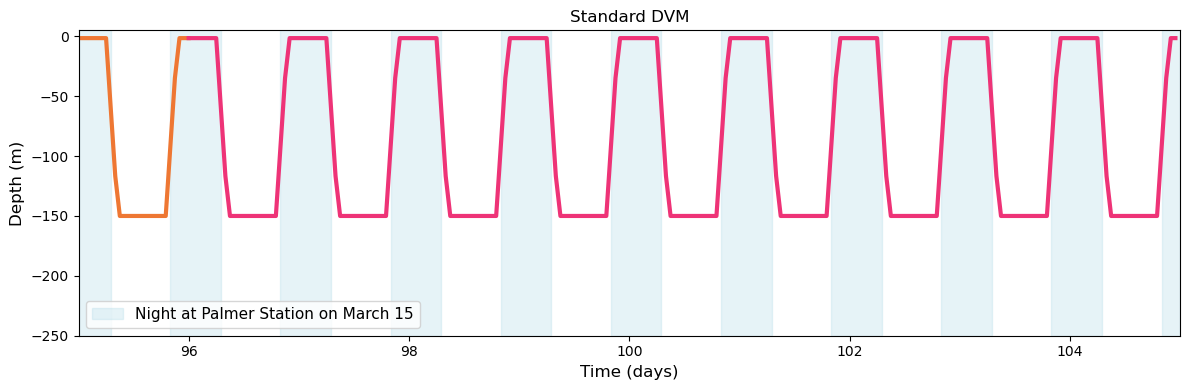

Plot saved to zoomed_dvm_deeper_dvm.png


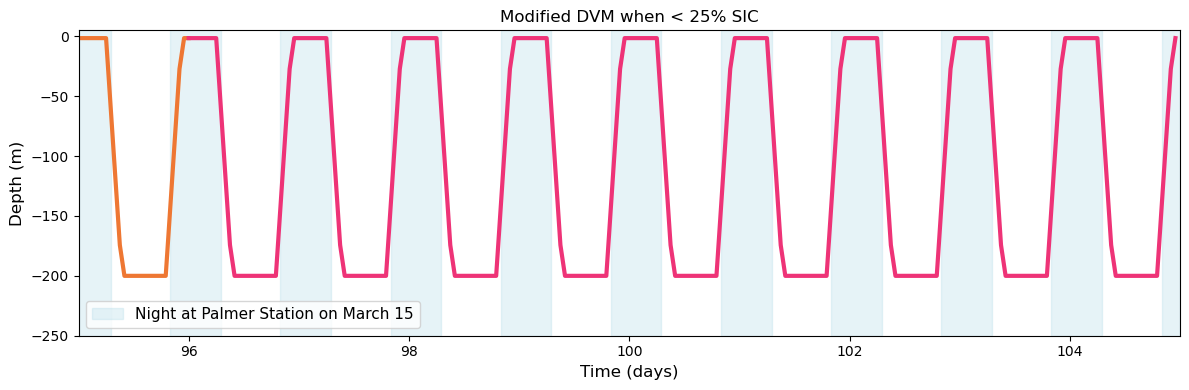

Plot saved to zoomed_dvm_reversed_dvm.png


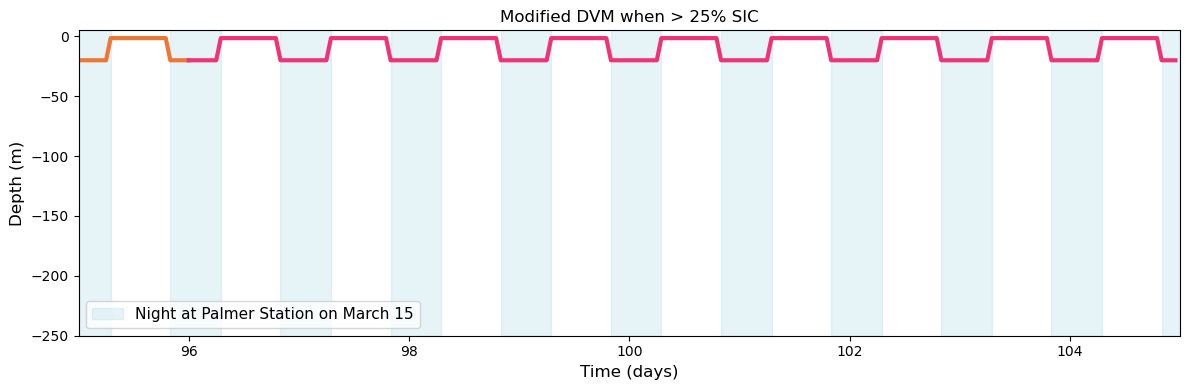

In [16]:
# Patterns list: (Plot Title, Hours, Depths, Description)
patterns = [
    ("Standard DVM", hours_s, depths_s, "Standard DVM"),
    ("Deeper DVM", hours_d, depths_d, "Modified DVM when < 25% SIC"),
    ("Reversed DVM", hours_r, depths_r, "Modified DVM when > 25% SIC"),
]

# Define location and zoom parameters
location = sunrise_sunset_times["palmer_station"]
loc_name = "Palmer Station"
loc_date = "March 15"
zoom_xlim = (95 * 24, 105 * 24)  # Day 95 to 105
zoom_ylim = (-250, 5)  # Depth range

# Loop through patterns and plot each
for title, hours, depths, description in patterns:
    dvm_zoom(
        hours=hours, depths=depths,
        stage_colors=stage_colors, stage_hour_ranges=stage_hour_ranges,
        location=location, title=f"{description}",
        loc_name=loc_name, loc_date=loc_date,
        zoom_xlim=zoom_xlim, zoom_ylim=zoom_ylim,
        save_path=f"zoomed_dvm_{title.replace(' ', '_').lower()}.png"
    )

In [17]:
def combined_dvm_plot(
    patterns, stage_colors, stage_hour_ranges, location, 
    loc_name=None, loc_date=None, zoom_xlim=(95 * 24, 105 * 24), 
    zoom_ylim=(-250, 5), save_path=None
):
    """
    Creates a combined plot of all DVM patterns in a single figure.

    Parameters:
    - patterns: List of tuples (title, hours, depths, description) for each DVM type.
    - stage_colors: Dictionary of stage colors.
    - stage_hour_ranges: Dictionary of stage hour ranges.
    - location: Dictionary containing sunrise and sunset times.
    - loc_name: Optional string for the location name.
    - loc_date: Optional string for the date.
    - zoom_xlim: Tuple (min_hour, max_hour) for the x-axis zoom.
    - zoom_ylim: Tuple (min_depth, max_depth) for the y-axis zoom.
    - save_path: Optional path to save the figure.
    """
    if "sunrise" not in location or "sunset" not in location:
        raise ValueError("Location must include 'sunrise' and 'sunset' times.")
    
    sunrise_hour = location["sunrise"]
    sunset_hour = location["sunset"]

    # Create the figure and subplots
    fig, axes = plt.subplots(len(patterns), 1, figsize=(9, 7), sharex=True, constrained_layout=True)
    if len(patterns) == 1:  # If there's only one row, make `axes` iterable
        axes = [axes]

    # Plot each DVM pattern
    for ax, (title, hours, depths, description) in zip(axes, patterns):
        ax.set_title(description)#, fontsize=12)

        # Determine night blocks within the zoom_xlim
        start_hour = int(zoom_xlim[0])
        end_hour = int(zoom_xlim[1])
        current_block_start = None

        for hour in range(start_hour, end_hour):
            day_fraction = hour % 24  # Hour within the day
            if not (sunrise_hour <= day_fraction < sunset_hour):  # Nighttime
                if current_block_start is None:
                    current_block_start = hour  # Start of a night block
            else:  # Daytime
                if current_block_start is not None:
                    ax.axvspan(
                        current_block_start / 24, hour / 24,  # Convert hours to days
                        color='lightblue', alpha=0.3  # Night shading
                    )
                    current_block_start = None

        # If there's an ongoing night block at the end, close it
        if current_block_start is not None:
            ax.axvspan(
                current_block_start / 24, end_hour / 24,  # Convert hours to days
                color='lightblue', alpha=0.3
            )

        # Plot the DVM phase
        for stage, (start_hour, end_hour) in stage_hour_ranges.items():
            if end_hour < zoom_xlim[0] or start_hour > zoom_xlim[1]:
                continue
            
            start_idx = max(0, np.searchsorted(hours, max(start_hour, zoom_xlim[0])))
            end_idx = min(len(hours), np.searchsorted(hours, min(end_hour, zoom_xlim[1])))

            ax.plot(
                hours[start_idx:end_idx] / 24,  # Convert hours to days
                depths[start_idx:end_idx],
                color=stage_colors[stage], linewidth=3, label=f"{stages[stage]['label']} ({int(start_hour/24)}-{int(end_hour/24)} days)"
            )

        # Set zoomed axis limits
        ax.set_xlim(zoom_xlim[0] / 24, zoom_xlim[1] / 24)  # Convert hours to days
        ax.set_ylim(zoom_ylim)

        # Set y-axis label
        ax.set_ylabel("Depth (m)")#, fontsize=12)

        # Add legend only to the first subplot
        if ax == axes[2]:
            night_text = f"Night at {loc_name} on {loc_date}" if loc_name and loc_date else "Nighttime"
            night_patch = plt.Rectangle((0, 0), 1, 1, color='lightblue', alpha=0.3, label=night_text)
            ax.legend(handles=[night_patch], loc='lower left')#, fontsize=11)

    # Set x-axis label on the last subplot
    axes[-1].set_xlabel("Time (days)")#, fontsize=12)

    # Save the plot if save_path is provided
    if save_path:
        if isinstance(save_path, str):  # Check that save_path is a string
            plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
            print(f"Plot saved to {save_path}")
        else:
            print(f"Error: save_path must be a string, got {type(save_path)}")

    # Show the plot
    plt.show()

In [22]:
def combined_dvm_plot(
    patterns, stage_colors, stage_hour_ranges, location, 
    loc_name=None, loc_date=None, zoom_xlim=(95 * 24, 105 * 24), 
    zoom_ylim=(-250, 5), save_path=None
):
    """
    Creates a combined plot of all DVM patterns in a single figure with panel annotations (A, B, C).

    Parameters:
    - patterns: List of tuples (title, hours, depths, description) for each DVM type.
    - stage_colors: Dictionary of stage colors.
    - stage_hour_ranges: Dictionary of stage hour ranges.
    - location: Dictionary containing sunrise and sunset times.
    - loc_name: Optional string for the location name.
    - loc_date: Optional string for the date.
    - zoom_xlim: Tuple (min_hour, max_hour) for the x-axis zoom.
    - zoom_ylim: Tuple (min_depth, max_depth) for the y-axis zoom.
    - save_path: Optional path to save the figure.
    """
    if "sunrise" not in location or "sunset" not in location:
        raise ValueError("Location must include 'sunrise' and 'sunset' times.")
    
    sunrise_hour = location["sunrise"]
    sunset_hour = location["sunset"]

    # Create the figure and subplots
    fig, axes = plt.subplots(len(patterns), 1, figsize=(8, 8), sharex=True, constrained_layout=True)
    if len(patterns) == 1:  # If there's only one row, make `axes` iterable
        axes = [axes]

    # Plot each DVM pattern
    for i, (ax, (title, hours, depths, description)) in enumerate(zip(axes, patterns)):
        ax.set_title(description)#, fontsize=16)

        # Add panel annotation (A, B, C, ...)
        annotation = chr(65 + i)  # Convert 0 -> A, 1 -> B, 2 -> C, etc.
        ax.text(
            0.02, 1.1, f"{annotation})", transform=ax.transAxes, 
            fontsize=11, fontweight='bold', va='top', ha='left'
        )

        # Determine night blocks within the zoom_xlim
        start_hour = int(zoom_xlim[0])
        end_hour = int(zoom_xlim[1])
        current_block_start = None

        for hour in range(start_hour, end_hour):
            day_fraction = hour % 24  # Hour within the day
            if not (sunrise_hour <= day_fraction < sunset_hour):  # Nighttime
                if current_block_start is None:
                    current_block_start = hour  # Start of a night block
            else:  # Daytime
                if current_block_start is not None:
                    ax.axvspan(
                        current_block_start / 24, hour / 24,  # Convert hours to days
                        color='lightblue', alpha=0.3  # Night shading
                    )
                    current_block_start = None

        # If there's an ongoing night block at the end, close it
        if current_block_start is not None:
            ax.axvspan(
                current_block_start / 24, end_hour / 24,  # Convert hours to days
                color='lightblue', alpha=0.3
            )

        # Plot the DVM phase
        for stage, (start_hour, end_hour) in stage_hour_ranges.items():
            if end_hour < zoom_xlim[0] or start_hour > zoom_xlim[1]:
                continue
            
            start_idx = max(0, np.searchsorted(hours, max(start_hour, zoom_xlim[0])))
            end_idx = min(len(hours), np.searchsorted(hours, min(end_hour, zoom_xlim[1])))

            ax.plot(
                hours[start_idx:end_idx] / 24,  # Convert hours to days
                depths[start_idx:end_idx],
                color=stage_colors[stage], linewidth=3, label=f"{stages[stage]['label']} ({int(start_hour/24)}-{int(end_hour/24)} days)"
            )

        # Set zoomed axis limits
        ax.set_xlim(zoom_xlim[0] / 24, zoom_xlim[1] / 24)  # Convert hours to days
        ax.set_ylim(zoom_ylim)

        # Set y-axis label
        ax.set_ylabel("Depth (m)")#, fontsize=14)

        # Add legend only to the last subplot
        if ax == axes[2]:
            night_text = f"Night at {loc_name} on {loc_date}" if loc_name and loc_date else "Nighttime"
            night_patch = plt.Rectangle((0, 0), 1, 1, color='lightblue', alpha=0.3, label=night_text)
            ax.legend(handles=[night_patch], loc='lower left')#, fontsize=10)

    # Set x-axis label on the last subplot
    axes[-1].set_xlabel("Time (days)")#, fontsize=14)

    # Save the plot if save_path is provided
    if save_path:
        if isinstance(save_path, str):  # Check that save_path is a string
            plt.savefig(save_path, dpi=100, bbox_inches='tight', pad_inches=0.1)
            print(f"Plot saved to {save_path}")
        else:
            print(f"Error: save_path must be a string, got {type(save_path)}")

    # Show the plot
    plt.show()

Plot saved to figures/manuscript-versions/fig_4_4_retention.pdf


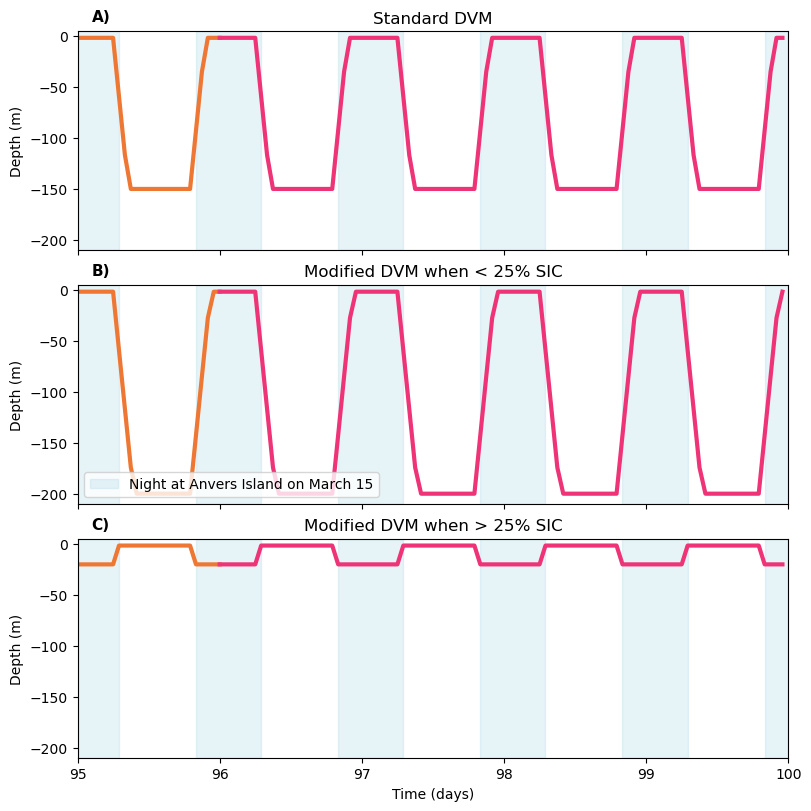

In [23]:
# Patterns list: (Plot Title, Hours, Depths, Description)
patterns = [
    ("Standard DVM", hours_s, depths_s, "Standard DVM"),
    ("Deeper DVM", hours_d, depths_d, "Modified DVM when < 25% SIC"),
    ("Reversed DVM", hours_r, depths_r, "Modified DVM when > 25% SIC"),
]

# Define location and zoom parameters
location = sunrise_sunset_times["palmer_station"]
loc_name = "Anvers Island"
loc_date = "March 15"
zoom_xlim = (95 * 24, 100 * 24)  # Day 95 to 105
zoom_ylim = (-210, 5)  # Depth range

# Generate the combined plot
combined_dvm_plot(
    patterns=patterns,
    stage_colors=stage_colors,
    stage_hour_ranges=stage_hour_ranges,
    location=location,
    loc_name=loc_name,
    loc_date=loc_date,
    zoom_xlim=zoom_xlim,
    zoom_ylim=zoom_ylim,
    # save_path=f"figures/manuscript-versions/Figure-3-dvm_schematic-resize.png",
    save_path=f"figures/manuscript-versions/fig_4_4_retention.pdf"
)

In [25]:
# 2 panel

In [30]:
def combined_dvm_plot(
    patterns, stage_colors, stage_hour_ranges, location, 
    loc_name=None, loc_date=None, zoom_xlim=(95 * 24, 105 * 24), 
    zoom_ylim=(-250, 5), save_path=None
):
    """
    Creates a combined plot of all DVM patterns in a single figure with panel annotations (A, B, C).

    Parameters:
    - patterns: List of tuples (title, hours, depths, description) for each DVM type.
    - stage_colors: Dictionary of stage colors.
    - stage_hour_ranges: Dictionary of stage hour ranges.
    - location: Dictionary containing sunrise and sunset times.
    - loc_name: Optional string for the location name.
    - loc_date: Optional string for the date.
    - zoom_xlim: Tuple (min_hour, max_hour) for the x-axis zoom.
    - zoom_ylim: Tuple (min_depth, max_depth) for the y-axis zoom.
    - save_path: Optional path to save the figure.
    """
    if "sunrise" not in location or "sunset" not in location:
        raise ValueError("Location must include 'sunrise' and 'sunset' times.")
    
    sunrise_hour = location["sunrise"]
    sunset_hour = location["sunset"]

    # Create the figure and subplots
    fig, axes = plt.subplots(len(patterns), 1, figsize=(8, 5), sharex=True, constrained_layout=True)
    if len(patterns) == 1:  # If there's only one row, make `axes` iterable
        axes = [axes]

    # Plot each DVM pattern
    for i, (ax, (title, hours, depths, description)) in enumerate(zip(axes, patterns)):
        ax.set_title(description)#, fontsize=16)

        # Add panel annotation (A, B, C, ...)
        annotation = chr(65 + i)  # Convert 0 -> A, 1 -> B, 2 -> C, etc.
        ax.text(
            0.02, 1.1, f"{annotation}", transform=ax.transAxes, 
            fontsize=11, fontweight='bold', va='top', ha='left'
        )

        # Determine night blocks within the zoom_xlim
        start_hour = int(zoom_xlim[0])
        end_hour = int(zoom_xlim[1])
        current_block_start = None

        for hour in range(start_hour, end_hour):
            day_fraction = hour % 24  # Hour within the day
            if not (sunrise_hour <= day_fraction < sunset_hour):  # Nighttime
                if current_block_start is None:
                    current_block_start = hour  # Start of a night block
            else:  # Daytime
                if current_block_start is not None:
                    ax.axvspan(
                        current_block_start / 24, hour / 24,  # Convert hours to days
                        color='lightblue', alpha=0.3  # Night shading
                    )
                    current_block_start = None

        # If there's an ongoing night block at the end, close it
        if current_block_start is not None:
            ax.axvspan(
                current_block_start / 24, end_hour / 24,  # Convert hours to days
                color='lightblue', alpha=0.3
            )

        # Plot the DVM phase
        for stage, (start_hour, end_hour) in stage_hour_ranges.items():
            if end_hour < zoom_xlim[0] or start_hour > zoom_xlim[1]:
                continue
            
            start_idx = max(0, np.searchsorted(hours, max(start_hour, zoom_xlim[0])))
            end_idx = min(len(hours), np.searchsorted(hours, min(end_hour, zoom_xlim[1])))

            ax.plot(
                hours[start_idx:end_idx] / 24,  # Convert hours to days
                depths[start_idx:end_idx],
                color=stage_colors[stage], linewidth=3, label=f"{stages[stage]['label']} ({int(start_hour/24)}-{int(end_hour/24)} days)"
            )

        # Set zoomed axis limits
        ax.set_xlim(zoom_xlim[0] / 24, zoom_xlim[1] / 24)  # Convert hours to days
        ax.set_ylim(zoom_ylim)

        # Set y-axis label
        ax.set_ylabel("Depth (m)")#, fontsize=14)

        # Add legend only to the last subplot
        if ax == axes[1]:
            night_text = f"Night at {loc_name} on {loc_date}" if loc_name and loc_date else "Nighttime"
            night_patch = plt.Rectangle((0, 0), 1, 1, color='lightblue', alpha=0.3, label=night_text)
            ax.legend(handles=[night_patch], loc='lower left')#, fontsize=10)

    # Set x-axis label on the last subplot
    axes[-1].set_xlabel("Time (days)")#, fontsize=14)

    # Save the plot if save_path is provided
    if save_path:
        if isinstance(save_path, str):  # Check that save_path is a string
            plt.savefig(save_path, dpi=100, bbox_inches='tight', pad_inches=0.1)
            print(f"Plot saved to {save_path}")
        else:
            print(f"Error: save_path must be a string, got {type(save_path)}")

    # Show the plot
    plt.show()

Plot saved to figures/manuscript-versions/DVM-ice-no-ice.png


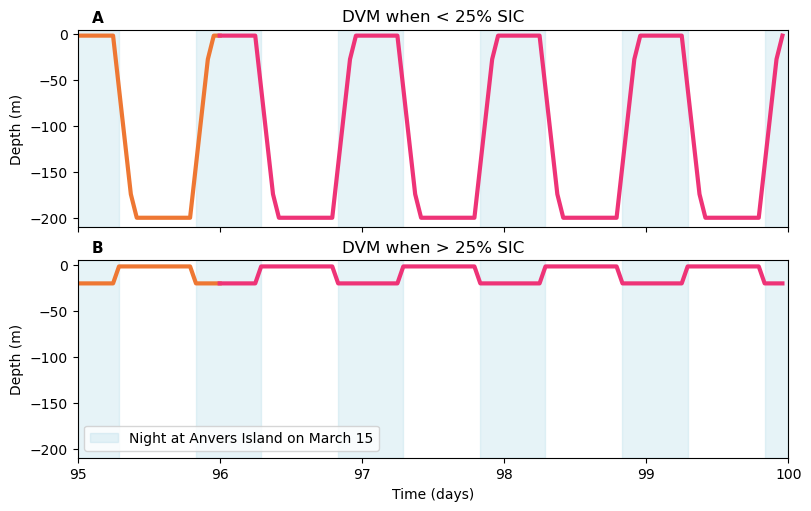

In [33]:
# Patterns list: (Plot Title, Hours, Depths, Description)
patterns = [
    ("Deeper DVM", hours_d, depths_d, "DVM when < 25% SIC"),
    ("Reversed DVM", hours_r, depths_r, "DVM when > 25% SIC"),
]

# Define location and zoom parameters
location = sunrise_sunset_times["palmer_station"]
loc_name = "Anvers Island"
loc_date = "March 15"
zoom_xlim = (95 * 24, 100 * 24)  # Day 95 to 105
zoom_ylim = (-210, 5)  # Depth range

# Generate the combined plot
combined_dvm_plot(
    patterns=patterns,
    stage_colors=stage_colors,
    stage_hour_ranges=stage_hour_ranges,
    location=location,
    loc_name=loc_name,
    loc_date=loc_date,
    zoom_xlim=zoom_xlim,
    zoom_ylim=zoom_ylim,
    # save_path=f"figures/manuscript-versions/Figure-3-dvm_schematic-resize.png",
    save_path=f"figures/manuscript-versions/DVM-ice-no-ice.png"
)